In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib .pyplot as plt
import os
import pickle
from sklearn.model_selection import train_test_split
import plotly.express as px
import streamlit as st

In [6]:
os.chdir('D:\\topmentor\\Cohort 127_ML_ Day 46\\Cohort 127_ML_ Day 46\\Stremlit Deployment and PBI Dashboard\\')

In [7]:
car_data=pd.read_csv('car_data.csv')
display(car_data)

,index,Make,Model,Year,Trim,MSRP,Invoice Price,Used/New Price,Body Size,Body Style,Cylinders,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Highway Fuel Economy
0,0,Aston Martin,DBX707,2024,Base,"$242,000",NaN,"$242,000",Large,SUV,V8,Twin-Turbo,AWD,automatic,697 hp @ 6000 rpm,663 ft-lbs. @ 2750 rpm,20 mpg
1,1,Audi,A3,2024,Premium w/40 TFSI,"$35,800","$33,653","$35,800",Compact,Sedan,I4,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,37 mpg
2,2,Audi,A3,2024,Premium w/40 TFSI,"$37,800","$35,533","$37,800",Compact,Sedan,I4,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,34 mpg
3,3,Audi,A3,2024,Premium Plus w/40 TFSI,"$41,400","$38,917","$41,400",Compact,Sedan,I4,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,34 mpg
4,4,Audi,A3,2024,Premium Plus w/40 TFSI,"$39,400","$37,037","$39,400",Compact,Sedan,I4,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,37 mpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,6410,Nissan,Z,2023,Performance,"$50,990",NaN,"$50,990",Compact,Coupe,V6,Twin-Turbo,RWD,automatic,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,28 mpg
1606,6411,Nissan,Z,2023,Proto Spec,"$53,990",NaN,"$53,990",Compact,Coupe,V6,Twin-Turbo,RWD,automatic,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,28 mpg
1607,6412,Nissan,Z,2023,Proto Spec,"$53,990",NaN,"$53,990",Compact,Coupe,V6,Twin-Turbo,RWD,manual,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,24 mpg
1608,6413,Nissan,Z,2023,Sport,"$40,990",NaN,"$40,990",Compact,Coupe,V6,Twin-Turbo,RWD,manual,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,24 mpg


In [8]:
for column in car_data:
    unique_vals = np.unique(car_data[column].fillna('0'))
    nr_values = len(unique_vals)
    if nr_values <= 12:
        print('The number of values for feature {} :{} -- {}'.format(column, nr_values,unique_vals))
    else:
        print('The number of values for feature {} :{}'.format(column, nr_values))

The number of values for feature index :1610
The number of values for feature Make :7 -- ['Aston Martin' 'Audi' 'BMW' 'Bentley' 'Ford' 'Mercedes-Benz' 'Nissan']
The number of values for feature Model :150
The number of values for feature Year :2 -- [2023 2024]
The number of values for feature Trim :373
The number of values for feature MSRP :1317
The number of values for feature Invoice Price :944
The number of values for feature Used/New Price :1317
The number of values for feature Body Size :3 -- ['Compact' 'Large' 'Midsize']
The number of values for feature Body Style :12 -- ['Cargo Minivan' 'Cargo Van' 'Convertible' 'Convertible SUV' 'Coupe'
 'Hatchback' 'Passenger Minivan' 'Passenger Van' 'Pickup Truck' 'SUV'
 'Sedan' 'Wagon']
The number of values for feature Cylinders :10 -- ['0' 'I3' 'I4' 'I5' 'I6' 'V10' 'V12' 'V6' 'V8' 'W12']
The number of values for feature Engine Aspiration :6 -- ['Electric Motor' 'Naturally Aspirated' 'Supercharged' 'Turbocharged'
 'Twin-Turbo' 'Twincharged']

In [9]:
# to get the null values from car_data sets use below commands to see
print(car_data.isnull().sum())

index                     0
Make                      0
Model                     0
Year                      0
Trim                      0
MSRP                      0
Invoice Price           552
Used/New Price            0
Body Size                 0
Body Style                0
Cylinders               165
Engine Aspiration         0
Drivetrain                0
Transmission              0
Horsepower                5
Torque                   27
Highway Fuel Economy    424
dtype: int64


In [10]:
# now we have seen that invoice price,cylinders ,torque and highway fuel economy have some null values
# So will drop the columns 
car_data=car_data.drop(['Invoice Price','Cylinders','Highway Fuel Economy'],axis=1)
print(car_data.isnull().sum())

index                 0
Make                  0
Model                 0
Year                  0
Trim                  0
MSRP                  0
Used/New Price        0
Body Size             0
Body Style            0
Engine Aspiration     0
Drivetrain            0
Transmission          0
Horsepower            5
Torque               27
dtype: int64


0       697.0
1       201.0
2       201.0
3       201.0
4       201.0
        ...  
1605    400.0
1606    400.0
1607    400.0
1608    400.0
1609    400.0
Name: Horsepower, Length: 1610, dtype: float64

0       False
1       False
2       False
3       False
4       False
        ...  
1605    False
1606    False
1607    False
1608    False
1609    False
Name: Horsepower_No, Length: 1610, dtype: bool

In [11]:
car_data['Horsepower_No']= car_data['Horsepower'].str[0:3].astype(float)

In [12]:
# now check the null values in the horsepower_no
display(car_data[car_data['Horsepower_No'].isna()])

,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Horsepower_No
371,971,Ford,F-150 Lightning,2024,Flash,"$67,995","$67,995",Large,Pickup Truck,Electric Motor,4WD,automatic,NaN,NaN,NaN
372,972,Ford,F-150 Lightning,2024,Lariat,"$76,995","$76,995",Large,Pickup Truck,Electric Motor,4WD,automatic,NaN,NaN,NaN
373,973,Ford,F-150 Lightning,2024,Platinum,"$84,995","$84,995",Large,Pickup Truck,Electric Motor,4WD,automatic,NaN,NaN,NaN
374,974,Ford,F-150 Lightning,2024,Pro,"$54,995","$54,995",Large,Pickup Truck,Electric Motor,4WD,automatic,NaN,NaN,NaN
375,975,Ford,F-150 Lightning,2024,XLT,"$62,995","$62,995",Large,Pickup Truck,Electric Motor,4WD,automatic,NaN,NaN,NaN


In [36]:
mean_horsepower=car_data['Horsepower_No'][car_data['Make']=='Ford'].mean()
mean_horsepower

np.float64(333.2254428341385)

In [53]:
car_data[car_data['Horsepower_No'].isnull()]

,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Horsepower_No


In [52]:
car_data[car_data['Horsepower_No'].isna()]

,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Horsepower_No


In [51]:
car_data['Horsepower_No']=car_data['Horsepower_No'].fillna(mean_horsepower)
car_data['Horsepower']=car_data['Horsepower'].fillna(mean_horsepower)
display(car_data[car_data['Horsepower_No'].isna()])

,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Horsepower_No


In [54]:
car_data.isnull().sum()

index                 0
Make                  0
Model                 0
Year                  0
Trim                  0
MSRP                  0
Used/New Price        0
Body Size             0
Body Style            0
Engine Aspiration     0
Drivetrain            0
Transmission          0
Horsepower            0
Torque               27
Horsepower_No         0
dtype: int64

In [61]:
car_data.head(2)



,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Horsepower_No
0,0,Aston Martin,DBX707,2024,Base,"$242,000","$242,000",Large,SUV,Twin-Turbo,AWD,automatic,697 hp @ 6000 rpm,663 ft-lbs. @ 2750 rpm,697.0
1,1,Audi,A3,2024,Premium w/40 TFSI,"$35,800","$35,800",Compact,Sedan,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,201.0


In [62]:
car_data['Torque'].str[0:3].astype(float)

0       663.0
1       221.0
2       221.0
3       221.0
4       221.0
        ...  
1605    350.0
1606    350.0
1607    350.0
1608    350.0
1609    350.0
Name: Torque, Length: 1610, dtype: float64

In [64]:
car_data['Torque_No']=car_data['Torque'].str[0:3].astype(float)

In [77]:
car_data[car_data['Torque_No'].isna()].head(2)

,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Horsepower_No,Torque_No
42,42,Audi,Q4 Sportback e-tron,2024,Premium w/55,"$58,200","$58,200",Midsize,SUV,Electric Motor,AWD,automatic,335 hp @ 0 rpm,NaN,335.0,NaN
44,44,Audi,Q4 Sportback e-tron,2024,Premium Plus w/55,"$62,900","$62,900",Midsize,SUV,Electric Motor,AWD,automatic,335 hp @ 0 rpm,NaN,335.0,NaN


In [79]:
mean_torque=car_data['Torque_No'].mean()
mean_torque

np.float64(364.9734680985471)

In [81]:
car_data['Torque_No']=car_data['Torque_No'].fillna(mean_torque)
car_data['Torque']=car_data['Torque'].fillna(mean_torque)
display(car_data.isna().sum())

index                0
Make                 0
Model                0
Year                 0
Trim                 0
MSRP                 0
Used/New Price       0
Body Size            0
Body Style           0
Engine Aspiration    0
Drivetrain           0
Transmission         0
Horsepower           0
Torque               0
Horsepower_No        0
Torque_No            0
dtype: int64

In [82]:
display(car_data.dtypes)

index                  int64
Make                  object
Model                 object
Year                   int64
Trim                  object
MSRP                  object
Used/New Price        object
Body Size             object
Body Style            object
Engine Aspiration     object
Drivetrain            object
Transmission          object
Horsepower            object
Torque                object
Horsepower_No        float64
Torque_No            float64
dtype: object

In [84]:
car_data['MSRP']=car_data['MSRP'].str.replace('$','')
car_data['MSRP']=car_data['MSRP'].str.replace(',','').astype(float)
display(car_data)

,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Horsepower_No,Torque_No
0,0,Aston Martin,DBX707,2024,Base,242000.0,"$242,000",Large,SUV,Twin-Turbo,AWD,automatic,697 hp @ 6000 rpm,663 ft-lbs. @ 2750 rpm,697.0,663.0
1,1,Audi,A3,2024,Premium w/40 TFSI,35800.0,"$35,800",Compact,Sedan,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,201.0,221.0
2,2,Audi,A3,2024,Premium w/40 TFSI,37800.0,"$37,800",Compact,Sedan,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,201.0,221.0
3,3,Audi,A3,2024,Premium Plus w/40 TFSI,41400.0,"$41,400",Compact,Sedan,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,201.0,221.0
4,4,Audi,A3,2024,Premium Plus w/40 TFSI,39400.0,"$39,400",Compact,Sedan,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,201.0,221.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,6410,Nissan,Z,2023,Performance,50990.0,"$50,990",Compact,Coupe,Twin-Turbo,RWD,automatic,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0
1606,6411,Nissan,Z,2023,Proto Spec,53990.0,"$53,990",Compact,Coupe,Twin-Turbo,RWD,automatic,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0
1607,6412,Nissan,Z,2023,Proto Spec,53990.0,"$53,990",Compact,Coupe,Twin-Turbo,RWD,manual,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0
1608,6413,Nissan,Z,2023,Sport,40990.0,"$40,990",Compact,Coupe,Twin-Turbo,RWD,manual,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0


In [85]:
car_data['Used/New Price']=car_data['Used/New Price'].str.replace('$','')
car_data['Used/New Price']=car_data['Used/New Price'].str.replace(',','').astype(float)
display(car_data)

,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Horsepower_No,Torque_No
0,0,Aston Martin,DBX707,2024,Base,242000.0,242000.0,Large,SUV,Twin-Turbo,AWD,automatic,697 hp @ 6000 rpm,663 ft-lbs. @ 2750 rpm,697.0,663.0
1,1,Audi,A3,2024,Premium w/40 TFSI,35800.0,35800.0,Compact,Sedan,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,201.0,221.0
2,2,Audi,A3,2024,Premium w/40 TFSI,37800.0,37800.0,Compact,Sedan,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,201.0,221.0
3,3,Audi,A3,2024,Premium Plus w/40 TFSI,41400.0,41400.0,Compact,Sedan,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,201.0,221.0
4,4,Audi,A3,2024,Premium Plus w/40 TFSI,39400.0,39400.0,Compact,Sedan,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,201.0,221.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,6410,Nissan,Z,2023,Performance,50990.0,50990.0,Compact,Coupe,Twin-Turbo,RWD,automatic,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0
1606,6411,Nissan,Z,2023,Proto Spec,53990.0,53990.0,Compact,Coupe,Twin-Turbo,RWD,automatic,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0
1607,6412,Nissan,Z,2023,Proto Spec,53990.0,53990.0,Compact,Coupe,Twin-Turbo,RWD,manual,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0
1608,6413,Nissan,Z,2023,Sport,40990.0,40990.0,Compact,Coupe,Twin-Turbo,RWD,manual,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0


In [98]:
# we will co-relation matrix that is used below to get outliers and it only works non-string data.
cm=car_data.iloc[:,[5,6,14,15]]
cm

,MSRP,Used/New Price,Horsepower_No,Torque_No
0,242000.0,242000.0,697.0,663.0
1,35800.0,35800.0,201.0,221.0
2,37800.0,37800.0,201.0,221.0
3,41400.0,41400.0,201.0,221.0
4,39400.0,39400.0,201.0,221.0
...,...,...,...,...
1605,50990.0,50990.0,400.0,350.0
1606,53990.0,53990.0,400.0,350.0
1607,53990.0,53990.0,400.0,350.0
1608,40990.0,40990.0,400.0,350.0


In [99]:
cm.corr()

,MSRP,Used/New Price,Horsepower_No,Torque_No
MSRP,1.000000,1.000000,0.703226,0.620070
Used/New Price,1.000000,1.000000,0.703226,0.620070
Horsepower_No,0.703226,0.703226,1.000000,0.785578
Torque_No,0.620070,0.620070,0.785578,1.000000


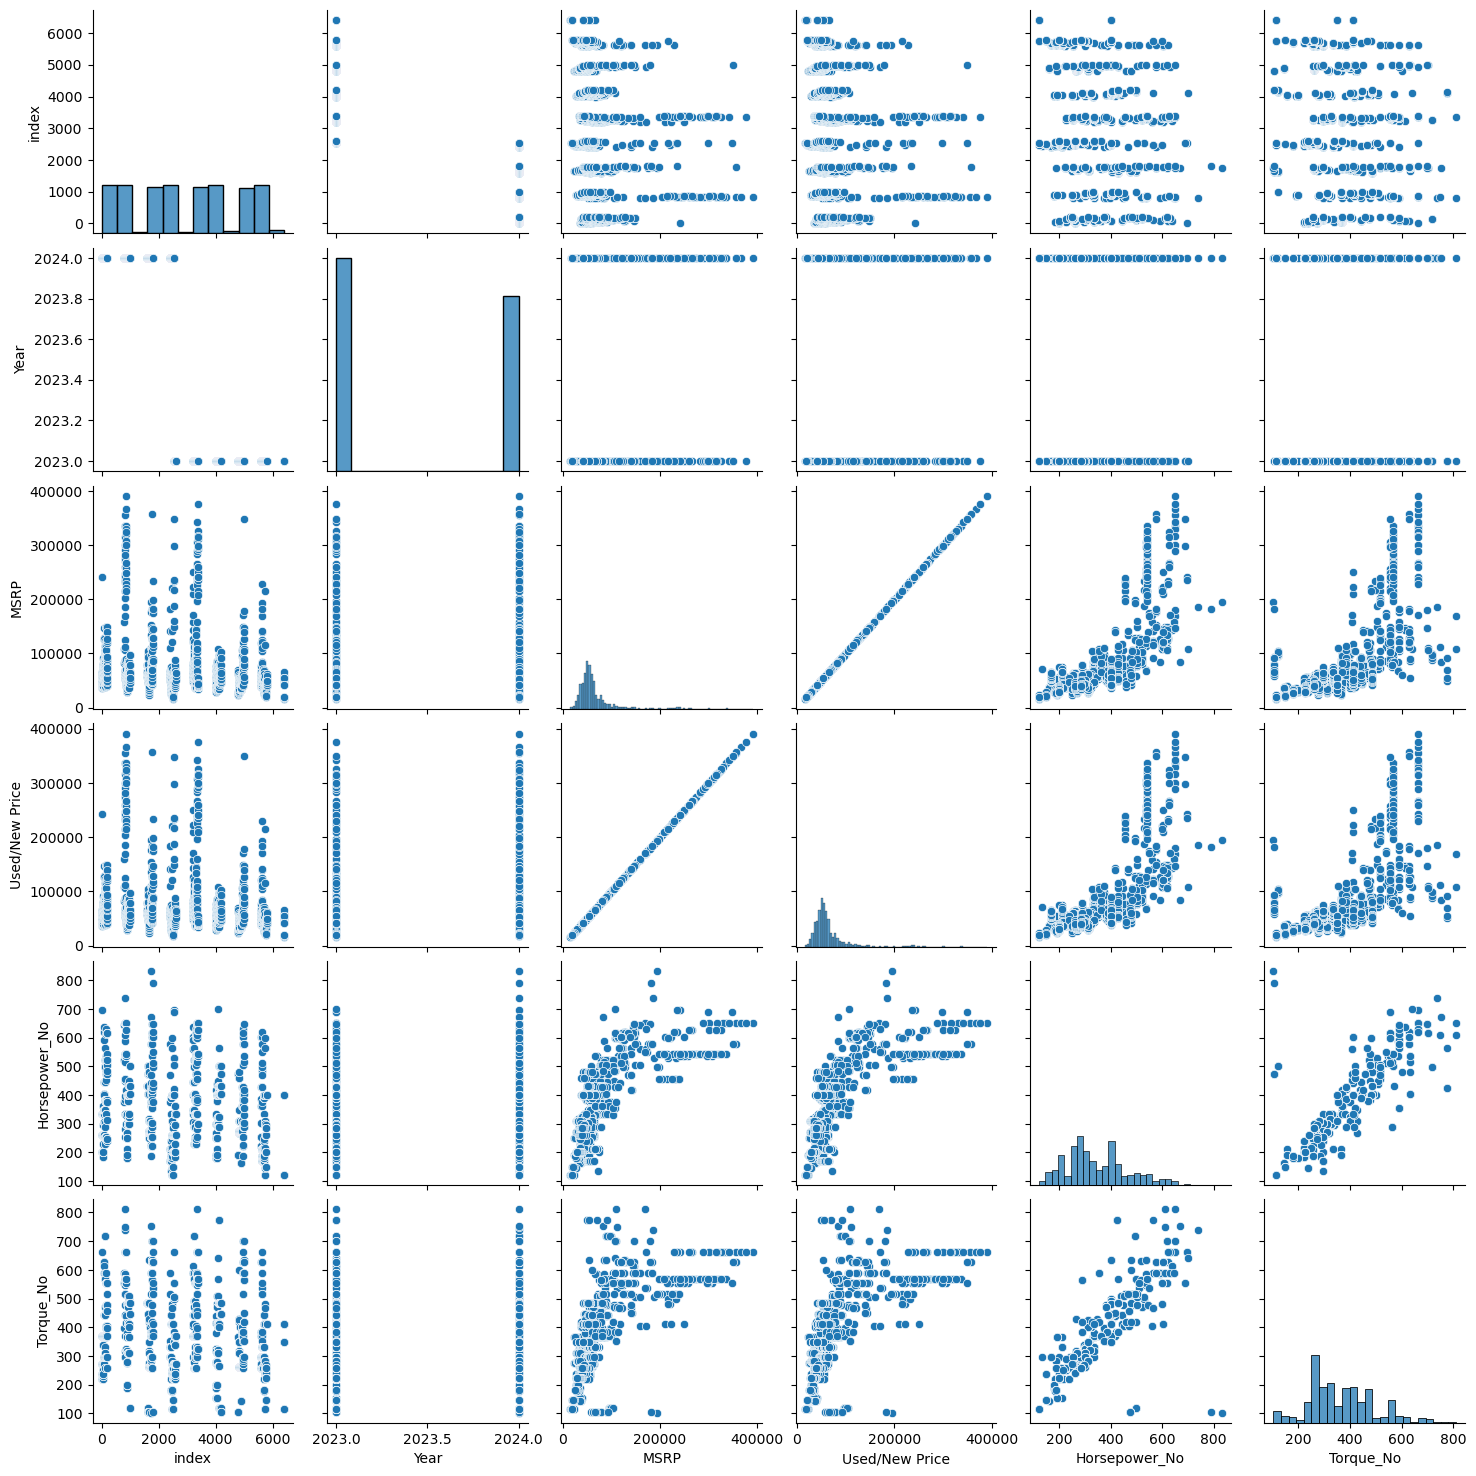

In [87]:
# to check outlier means we are checking the incorrect value or left or right skewed means value is in valid range 
sns.pairplot(car_data)
plt.grid(True,color='cyan')
plt.show()


In [100]:
car_data.head(2)

,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Horsepower_No,Torque_No
0,0,Aston Martin,DBX707,2024,Base,242000.0,242000.0,Large,SUV,Twin-Turbo,AWD,automatic,697 hp @ 6000 rpm,663 ft-lbs. @ 2750 rpm,697.0,663.0
1,1,Audi,A3,2024,Premium w/40 TFSI,35800.0,35800.0,Compact,Sedan,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,201.0,221.0


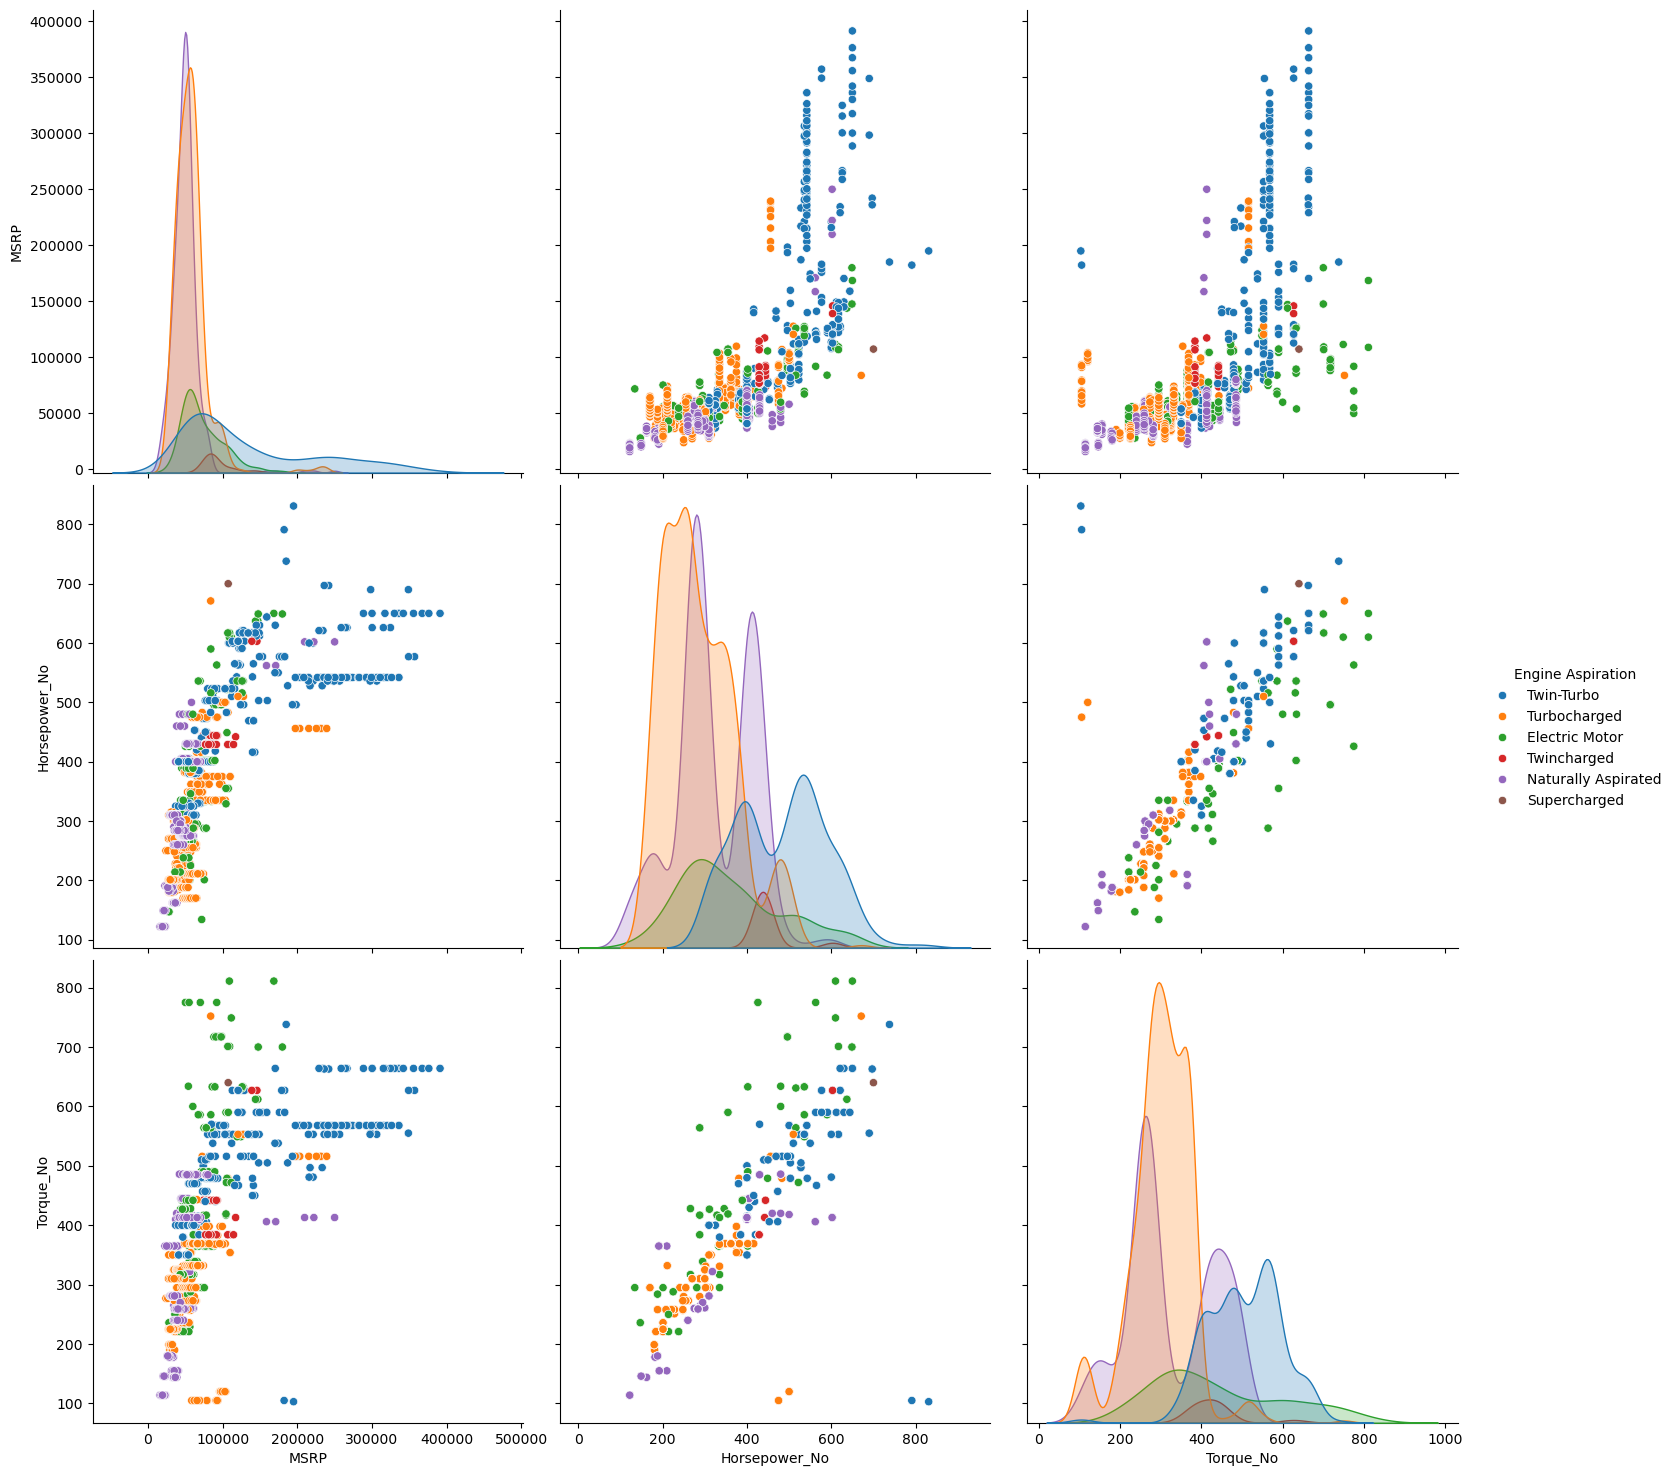

In [107]:
sns.pairplot(car_data[['MSRP','Horsepower_No','Torque_No','Engine Aspiration']],hue='Engine Aspiration',height=5)
plt.grid(True,color='k')
plt.show()

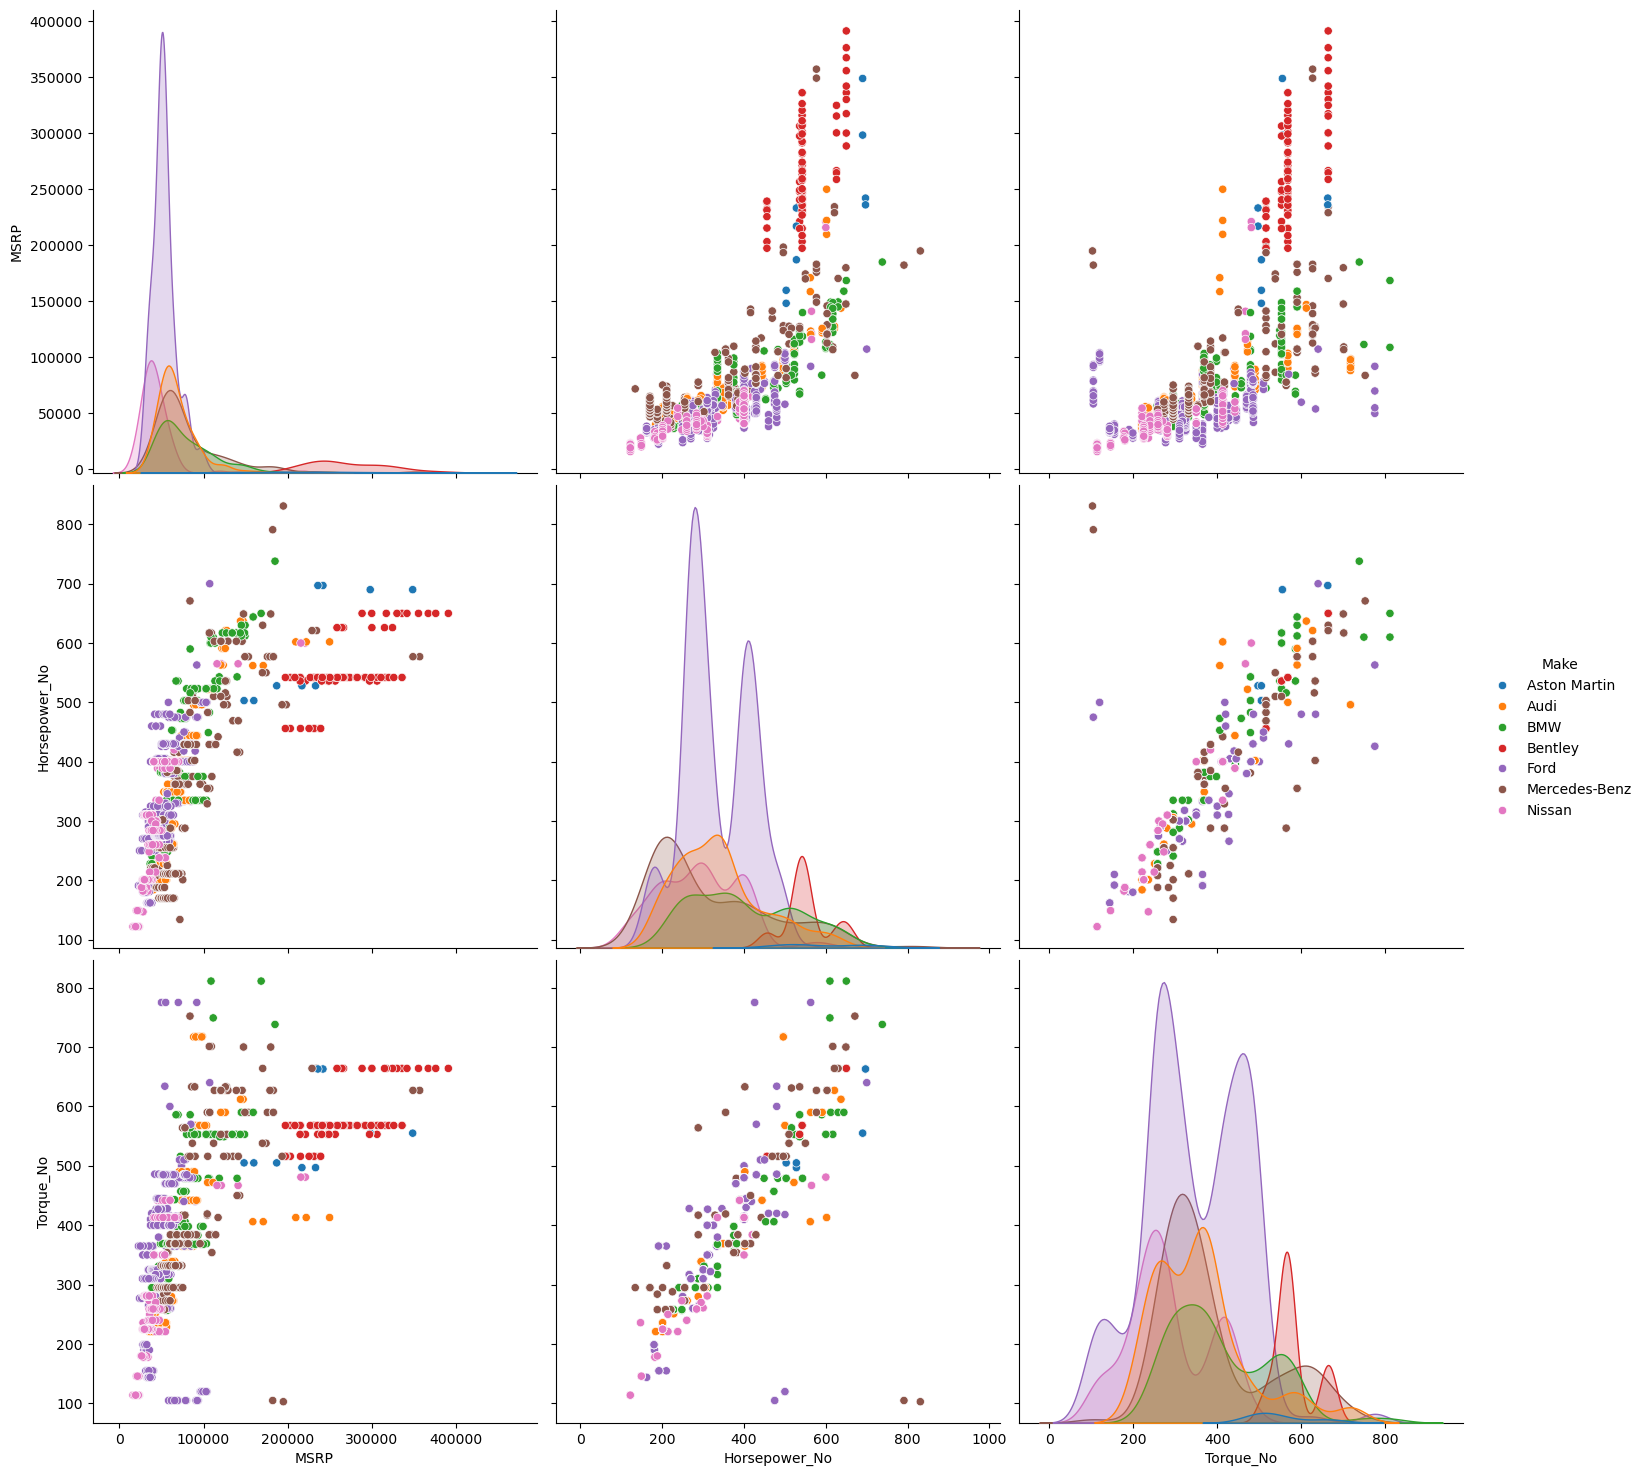

In [108]:
sns.pairplot(car_data[['MSRP','Horsepower_No','Torque_No','Make']],hue='Make',height=5)
plt.grid(True,color='k')
plt.show()

In [111]:
car_data.head(2)

,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Horsepower_No,Torque_No
0,0,Aston Martin,DBX707,2024,Base,242000.0,242000.0,Large,SUV,Twin-Turbo,AWD,automatic,697 hp @ 6000 rpm,663 ft-lbs. @ 2750 rpm,697.0,663.0
1,1,Audi,A3,2024,Premium w/40 TFSI,35800.0,35800.0,Compact,Sedan,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,201.0,221.0


In [112]:
# Above graph is used to classify the outliers in the data after the filling the values 
# now we will look into string data or categorical data and we will do the one hot encoding and label encoding based on the requirement 
categories=['Make','Body Size','Body Style','Engine Aspiration','Drivetrain','Transmission']



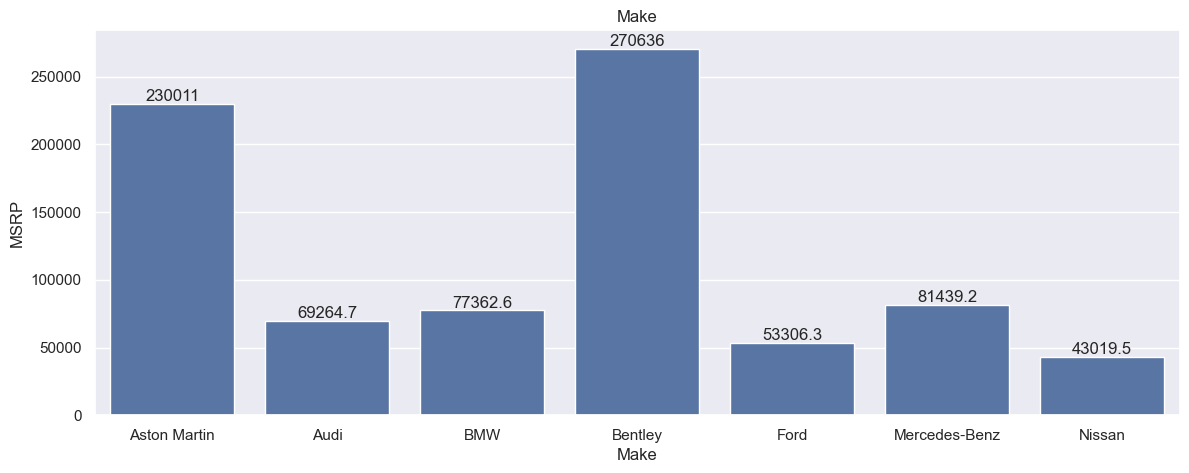

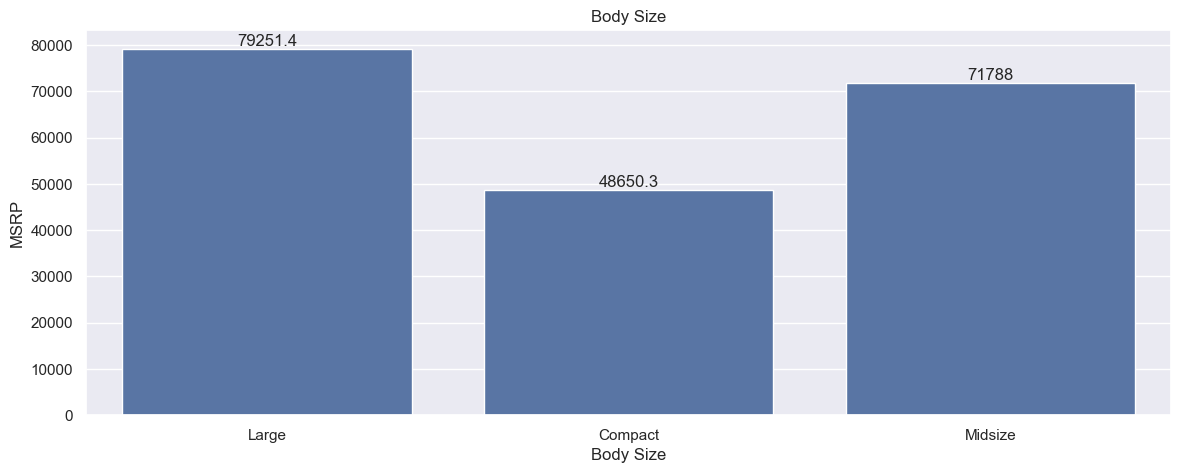

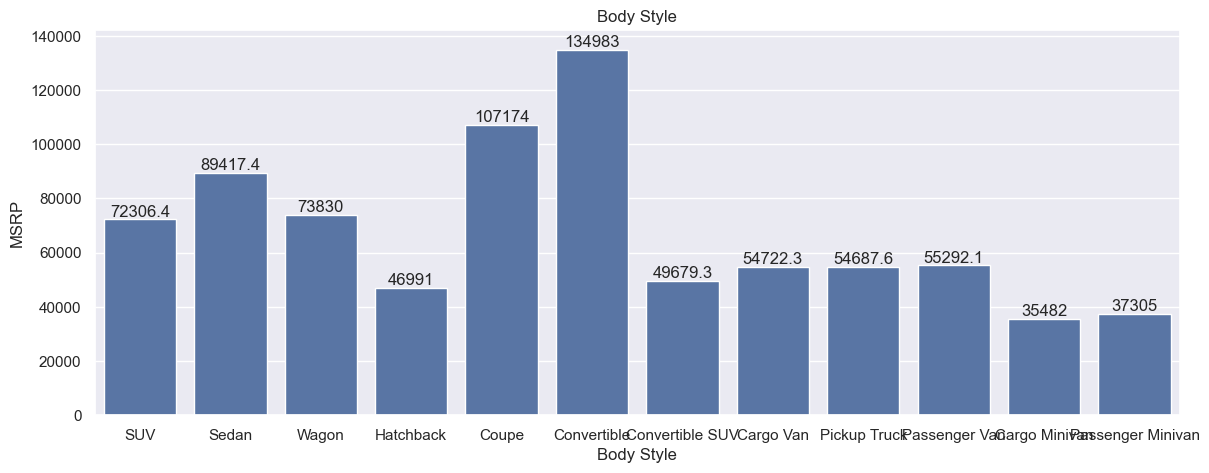

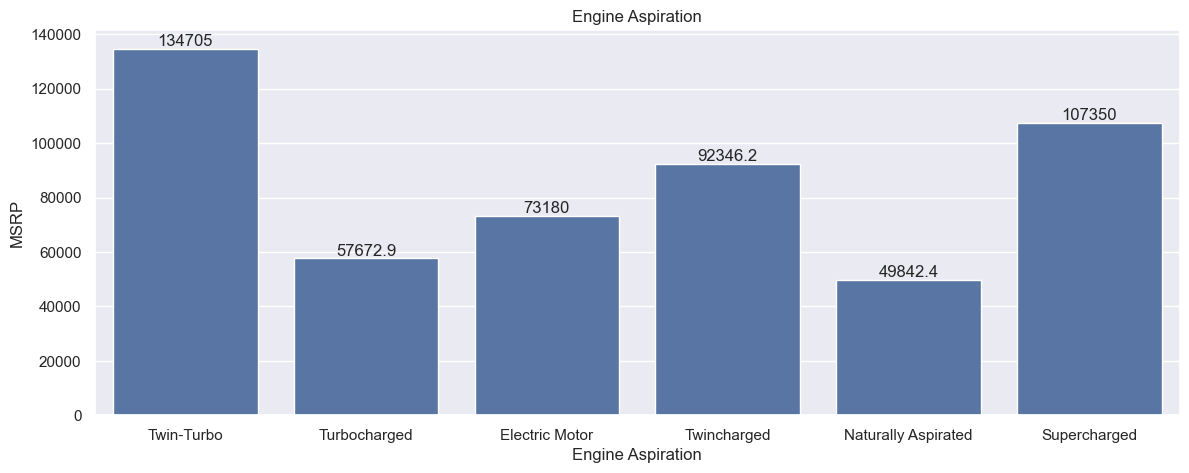

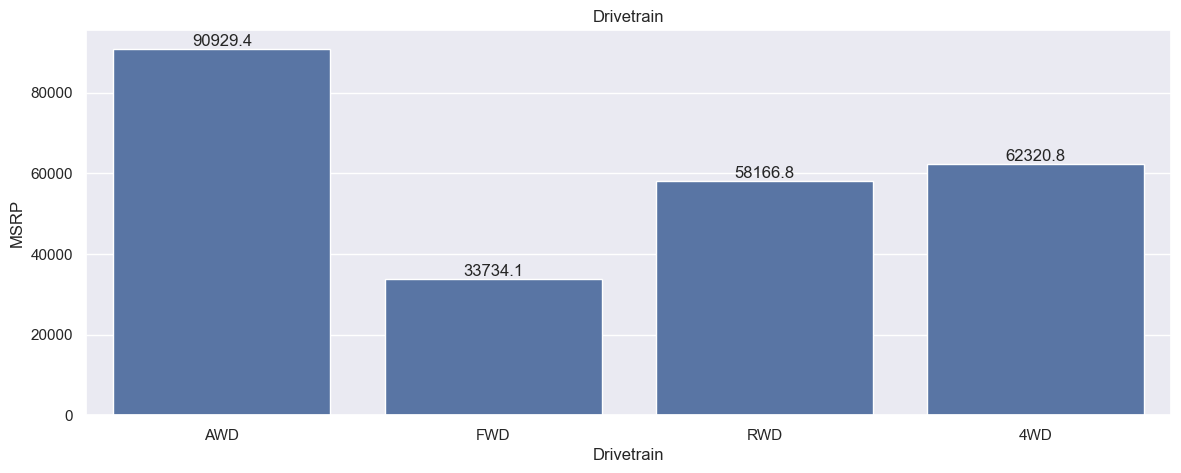

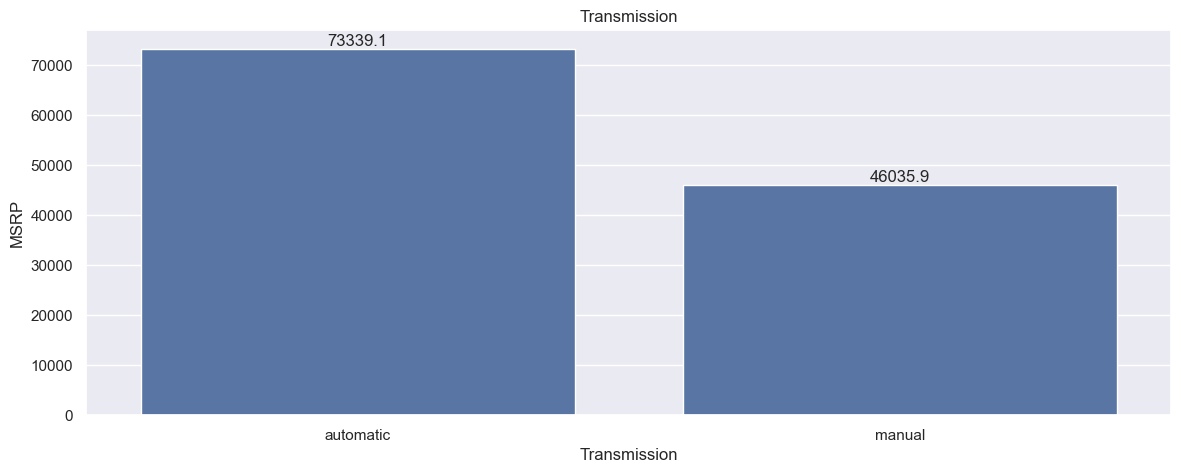

In [117]:
sns.set(rc={'figure.figsize':(14,5)})

for c in categories:
    ax=sns.barplot(x=c,y='MSRP',data=car_data,errorbar=('ci',False))
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(c)
    plt.show()

In [120]:
car_data['MSRP'].values

array([242000.,  35800.,  37800., ...,  53990.,  40990.,  40990.],
      shape=(1610,))

In [121]:
car_data['MSRP'].mean()

np.float64(72542.03229813665)

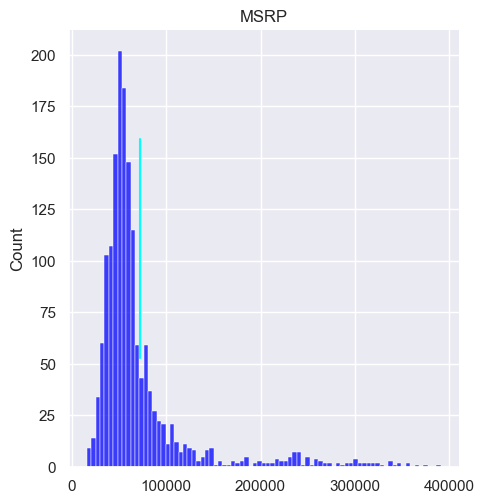

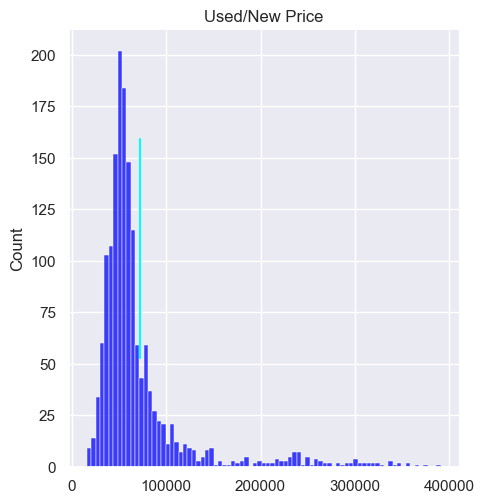

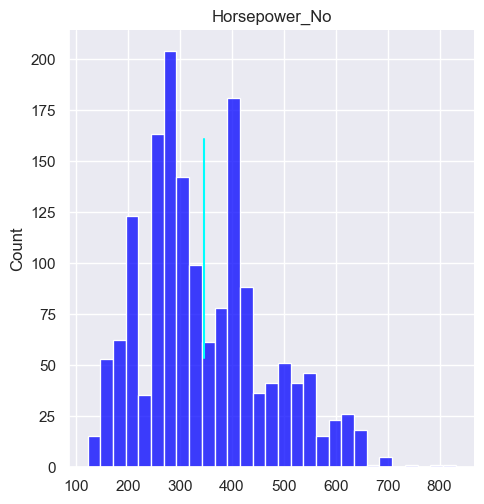

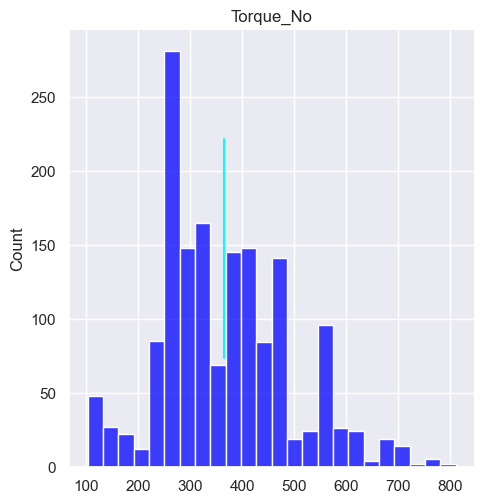

In [124]:
n_variables = ['MSRP','Used/New Price','Horsepower_No','Torque_No']
# size of sns plots
sns.set(rc={'figure.figsize':(10,5)})

for n in n_variables:
    x = car_data[n].values
    sns.displot(x, color = 'blue');
    # Calculating the mean
    mean = car_data[n].mean()
    
    # Plotting the mean- Plot line Y – Axis top to bottom 
    # plt.axvline() is a Matplotlib function that draws a vertical line on a plot.
    # x → the x-position of the vertical line (in your case, the variable mean)
    # ymin → bottom of the line (0 = bottom of plot)
    # ymax → top of the line (1 = top of plot) , color → line color
    plt.axvline(x= mean, ymin = .25,ymax=.75, color = 'cyan')
    plt.title(n)
    plt.show()


The median of  MSRP : 55945.0


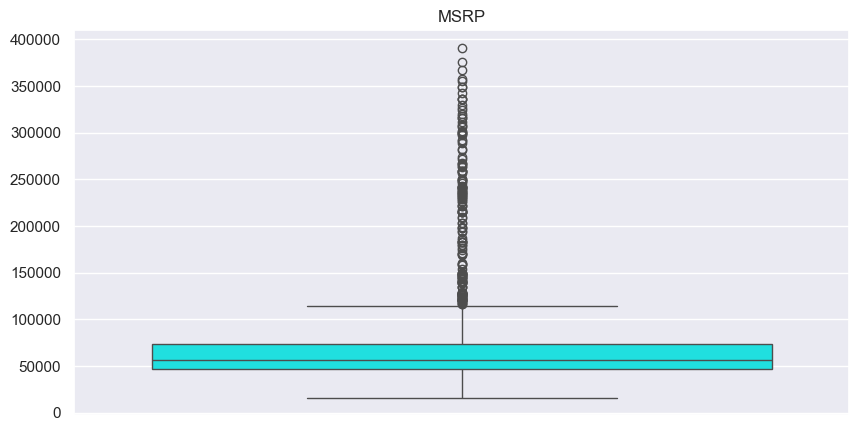

The median of  Used/New Price : 55945.0


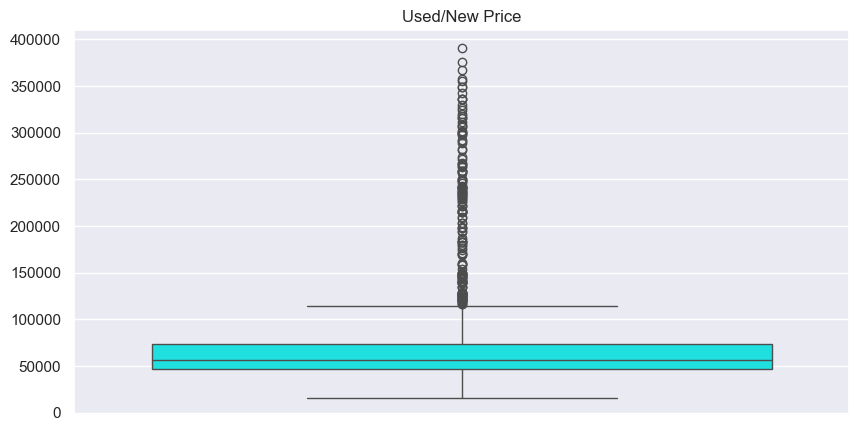

The median of  Horsepower_No : 325.0


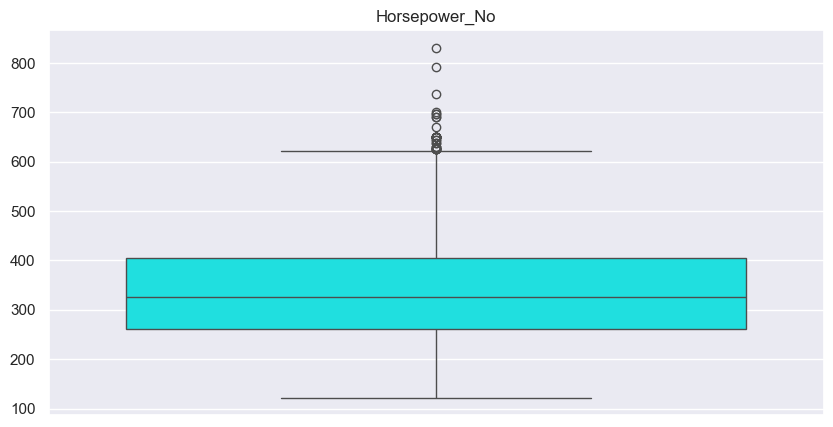

The median of  Torque_No : 350.0


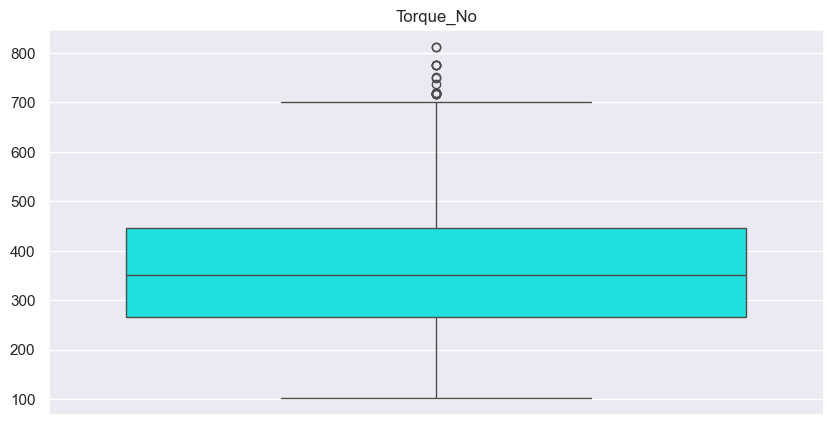

In [128]:
sns.set(rc={'figure.figsize':(10,5)})
for n in n_variables:
    x=car_data[n].values
    ax=sns.boxplot(x,color='cyan')
    print('The median of ',n,':',car_data[n].median())
    plt.title(n)
    plt.show()

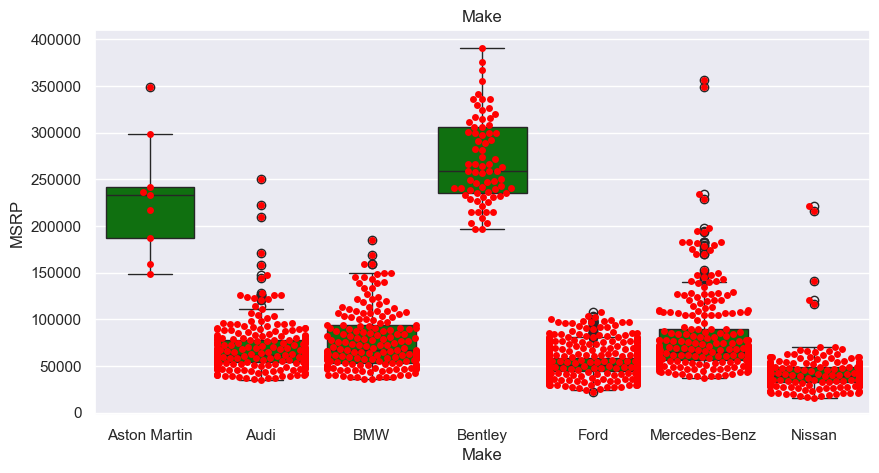

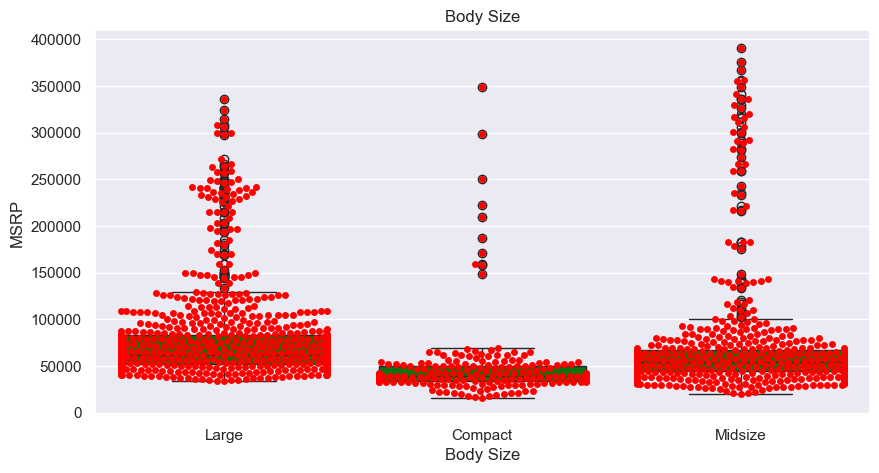

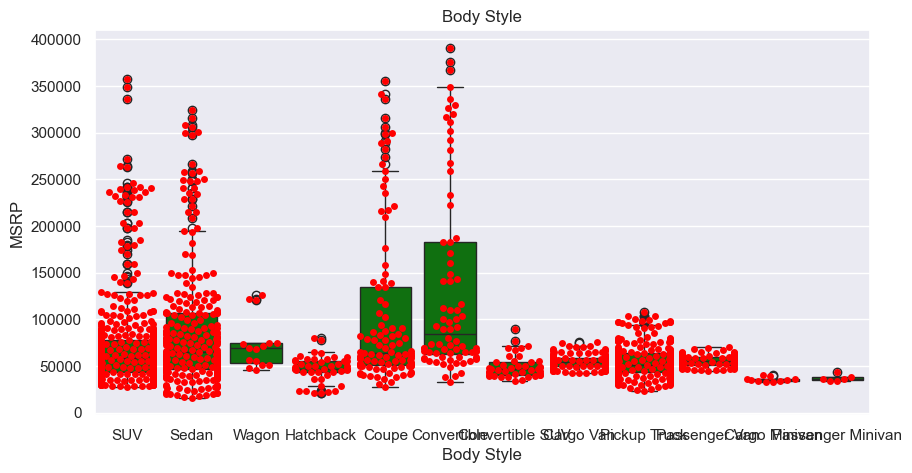

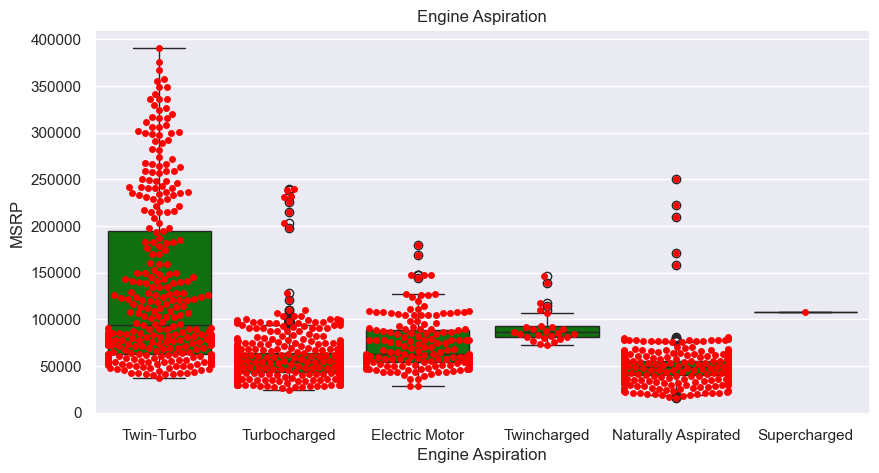

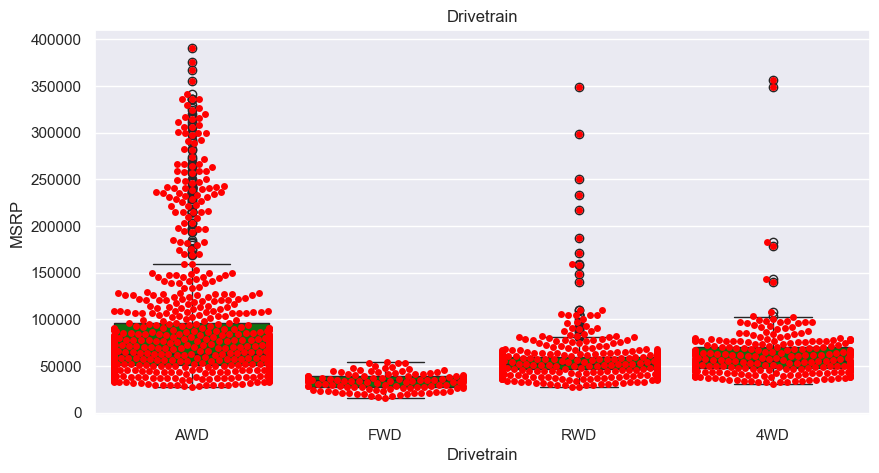

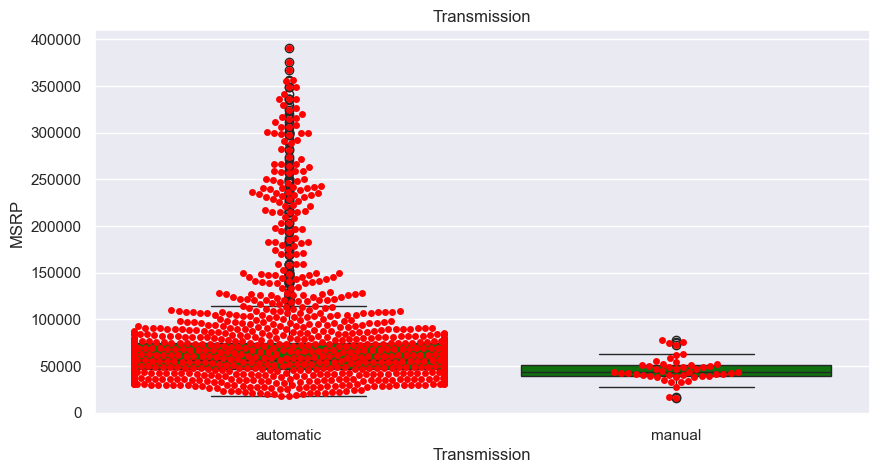

In [135]:
# now we can create one graph for all categorical data 
import warnings
warnings.filterwarnings('ignore')
for j in categories:
    ax=sns.boxplot(x=j,y='MSRP',data=car_data,color='green')
    ax=sns.swarmplot(x=j,y='MSRP',data=car_data,color='red')
    plt.title(j)
    plt.show()



In [137]:
car_data.head(2)

,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Horsepower_No,Torque_No
0,0,Aston Martin,DBX707,2024,Base,242000.0,242000.0,Large,SUV,Twin-Turbo,AWD,automatic,697 hp @ 6000 rpm,663 ft-lbs. @ 2750 rpm,697.0,663.0
1,1,Audi,A3,2024,Premium w/40 TFSI,35800.0,35800.0,Compact,Sedan,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,201.0,221.0


In [147]:
new_car_data=car_data.drop(['index','Model','Year','Trim','Used/New Price','Horsepower','Torque'],axis=1)
new_car_data.count()

Make                 1610
MSRP                 1610
Body Size            1610
Body Style           1610
Engine Aspiration    1610
Drivetrain           1610
Transmission         1610
Horsepower_No        1610
Torque_No            1610
dtype: int64

In [148]:
# Now we will do the one hot encoding using pd.get_dummies
new_car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               1610 non-null   object 
 1   MSRP               1610 non-null   float64
 2   Body Size          1610 non-null   object 
 3   Body Style         1610 non-null   object 
 4   Engine Aspiration  1610 non-null   object 
 5   Drivetrain         1610 non-null   object 
 6   Transmission       1610 non-null   object 
 7   Horsepower_No      1610 non-null   float64
 8   Torque_No          1610 non-null   float64
dtypes: float64(3), object(6)
memory usage: 113.3+ KB


In [149]:
new_car_data=pd.get_dummies(new_car_data,['Make','Body Size','Body Style','Engine Aspiration','Drivetrain','Transmission'],dtype='int')
new_car_data.head(5)

,MSRP,Horsepower_No,Torque_No,Make_Aston Martin,Make_Audi,Make_BMW,Make_Bentley,Make_Ford,Make_Mercedes-Benz,Make_Nissan,...,Engine Aspiration_Supercharged,Engine Aspiration_Turbocharged,Engine Aspiration_Twin-Turbo,Engine Aspiration_Twincharged,Drivetrain_4WD,Drivetrain_AWD,Drivetrain_FWD,Drivetrain_RWD,Transmission_automatic,Transmission_manual
0,242000.0,697.0,663.0,1,0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,1,0
1,35800.0,201.0,221.0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,1,0,1,0
2,37800.0,201.0,221.0,0,1,0,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0
3,41400.0,201.0,221.0,0,1,0,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0
4,39400.0,201.0,221.0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,1,0,1,0


In [150]:
new_car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 37 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   MSRP                                   1610 non-null   float64
 1   Horsepower_No                          1610 non-null   float64
 2   Torque_No                              1610 non-null   float64
 3   Make_Aston Martin                      1610 non-null   int64  
 4   Make_Audi                              1610 non-null   int64  
 5   Make_BMW                               1610 non-null   int64  
 6   Make_Bentley                           1610 non-null   int64  
 7   Make_Ford                              1610 non-null   int64  
 8   Make_Mercedes-Benz                     1610 non-null   int64  
 9   Make_Nissan                            1610 non-null   int64  
 10  Body Size_Compact                      1610 non-null   int64  
 11  Body

In [152]:
# Now our data is ready to separate for dependant and independant variable 
X=new_car_data.drop(['MSRP'],axis=1).values
print(X.shape)

(1610, 36)


In [153]:
y=new_car_data['MSRP'].astype(int)
print(y.shape)

(1610,)


In [155]:
# Now we will perform the train_test_split using model_selection from sklearn
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.80,test_size=0.2,random_state=15)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1288, 36)
(322, 36)
(1288,)
(322,)


In [161]:
# After train and test split , now we will choose the regression model because of continous output of MSRP
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,r2_score,explained_variance_score,mean_absolute_error,mean_squared_error
from math import sqrt
# Training the regression
lm=LinearRegression(fit_intercept=True)
lm.fit(X_train,y_train)
y_pred=lm.predict(X_train)
all_df_predict=lm.predict(X)
print(all_df_predict)

[234895.92720418  46510.11486585  38802.33920273 ...  56480.18864755
  56480.18864755  77269.2214777 ]


In [163]:
# Now we will check the accuracy 
print('The accuracy on the training dataset is:',lm.score(X_train,y_train))
print('The accuracy r2 on the training dataset prediction is:',r2_score(y_train,y_pred))

print("")

# model accuracy on the testing datasets
print('The accuracy on the testing dataset is:',lm.score(X_test,y_test))

print("")

# The root mean Squared error(RMSE)
print('The RMSE on the training dataset is:',sqrt(mean_squared_error(y_train,y_pred)))
print('The RMSE on the testing dataset is:',sqrt(mean_squared_error(y_test,lm.predict(X_test))))

print("")

# The Mean Absolute error (MAE)
print('The MAE on the training dataset is:',mean_absolute_error(y_train,y_pred))
print('The MAE on the testing dataset is:',mean_absolute_error(y_test,lm.predict(X_test)))

print("")

# Coefficents

print('Coefficient:',lm.coef_)

# Intercept

print('Intercept:',lm.intercept_)






The accuracy on the training dataset is: 0.895779183244086
The accuracy r2 on the training dataset prediction is: 0.895779183244086

The accuracy on the testing dataset is: 0.9198625302493008

The RMSE on the training dataset is: 17421.7784480966
The RMSE on the testing dataset is: 16534.594571973663

The MAE on the training dataset is: 10599.011937878484
The MAE on the testing dataset is: 11090.088349592683

Coefficient: [ 2.22742940e+02 -1.89829669e+01  5.56034182e+04 -2.91161207e+04
 -3.66042366e+04  1.16226113e+05 -4.43839570e+04 -1.62628570e+04
 -4.54623600e+04  9.29404094e+01 -1.88423591e+02  9.54831816e+01
  6.09802309e+02  8.15969817e+03  1.42360673e+04  1.18332658e+02
  6.41353581e+02 -4.42967483e+03  6.15846845e+03  8.27078966e+03
 -1.77754623e+04 -5.15286113e+03 -3.70758421e+03 -7.12892964e+03
  6.29975752e+03  1.80270043e+03 -1.34977391e+04 -2.53004586e+02
  1.07576585e+04 -5.10937274e+03  4.83989383e+03 -3.37471593e+03
  4.33305973e+03 -5.79823762e+03  1.03945164e+04 -1.03

In [164]:
pickle.dump(lm,open('linear_model.pkl','wb'))

In [165]:
model=pickle.load(open('linear_model.pkl','rb'))
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [166]:
print(model.predict(X_test))

[ 62610.21344473  59058.28801734  69804.26002918  59931.69406646
  70746.63250235  41994.57565936  17831.79225017  52918.76814526
  61222.2263992  281130.16720829  31886.17774607  48420.15656614
  50606.33794551  60642.95074555  50495.24645791  96988.25181222
  43865.56141546  59673.60063443  71026.87756879  69125.9956501
  61333.31788679  52508.2288527   53029.85963286  20722.88187777
  23681.68377395  53313.76640557  67378.48224702  20722.88187777
  72750.44303928 149532.16896274  18222.83912065  38444.44666506
  69125.9956501   17831.79225017  49737.06718941  71636.8363051
  64113.77316955  53029.85963286  41940.14530802  52918.76814526
  20937.43388617  27806.31521386  60193.63988714  71305.16611916
  85917.289306    46286.54033058  60938.31962649  31361.01332896
  65452.2055744   76177.36234463  18222.83912065  38802.33920273
  66630.462642    50606.33794551  50495.24645791  58412.72623973
  59058.28801734  20937.43388617  53029.85963286  65452.2055744
  23395.66309775  38802.3392